In [1]:
import pandas as pd
import numpy as np
import nibabel as nib
import ants
import os, fnmatch
from tqdm import tqdm_notebook
import matplotlib.pyplot as plt

In [2]:
#meta = pd.read_csv('/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/metafile_completing/metafile_ADDLpipeline_abeta_mri_02_06_2024.csv',header=[0], index_col=[0])
meta = pd.read_csv('/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/pet_mri_pairs.csv',header=[0], index_col=[0])
meta.reset_index(drop=True, inplace = True)
meta = meta.iloc[:,1:]

In [3]:
meta

,Project,Phase,Sex,Weight,Research.Group,VISCODE,Study.Date,Age,Modality,Description,...,pet_90q,pet_95q,pet_99q,pet_999q,mri_min,mri_max,mri_90q,mri_95q,mri_99q,mri_999q
0,A4,NaN,M,83.9,LEARN amyloidNE,SCV2,1/01/2016,84.4,PET,Florbetapir <- MNI_3DBRAIN_C),...,1.276597,1.580674,1.978580,2.227910,0.0,933.950256,333.807138,400.404616,561.022889,715.850910
1,ADNI,ADNI 2,M,84.9,LMCI,v21,9/30/2013,69.7,PET,"AV45 Co-registered, Averaged <- PET Brain AV_4...",...,1.461337,1.827432,2.423643,3.054871,0.0,961.956360,261.757932,355.890277,548.642743,712.191625
2,ADNI,ADNI 2,M,75.7,CN,v21,1/22/2014,79.2,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",...,1.946882,2.580722,3.634248,4.486002,0.0,929.178406,240.742639,331.720949,514.238646,689.266167
3,A4,NaN,M,71.4,amyloidE,SCV2,1/01/2016,82.5,PET,Florbetapir <- PET Scan,...,1.602751,1.971324,2.412896,3.200057,0.0,2612.348389,1167.067993,1346.653394,1690.529869,2097.628151
4,A4,NaN,F,0.0,LEARN amyloidNE,SCV2,1/01/2016,71.8,PET,Florbetapir <- PET Scan,...,1.264202,1.570734,1.938521,2.115626,0.0,829.836975,333.076224,385.074081,572.254060,664.659743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3105,ADNI,ADNI 2,F,76.7,CN,v31,1/07/2015,78.9,PET,"AV45 Co-registered, Averaged <- AV45_Dyn_4x5mi...",...,1.242392,1.675523,2.288885,2.970504,0.0,795.983521,275.498734,457.167799,570.447152,660.795371
3106,ADNI,ADNI GO,M,65.3,CN,m48,12/15/2010,89.3,PET,"AV45 Co-registered, Averaged <- 20 min 3D AV45...",...,1.343642,1.698786,2.172019,2.475094,0.0,3832.770020,1110.165137,1252.057654,2077.359536,2712.287479
3107,ADNI,ADNI 2,M,72.1,AD,v21,9/20/2013,81.5,PET,"AV45 Co-registered, Averaged <- Adni AV45 4 X ...",...,1.674981,1.898488,2.122555,2.313443,0.0,2352.499023,1103.067615,1169.376953,1870.213466,2206.189639
3108,ADNI,ADNI 2,M,57.5,CN,v31,9/17/2014,79.1,PET,"AV45 Co-registered, Averaged <- ADNIGO - AV45 ...",...,1.327106,1.655667,2.027242,2.220455,0.0,1047.075317,297.941159,318.847514,457.731591,631.311213


In [28]:
'''# Neuromorphometrics atlas
mni_t1 = ants.image_read('/csc/epitkane/home/atagmazi/Downloads/mni_icbm152_nlin_sym_09a_nifti/mni_icbm152_nlin_sym_09a/mni_icbm152_t1_tal_nlin_sym_09a.nii')

brain_labels = pd.read_xml('/csc/epitkane/home/atagmazi/labels_Neuromorphometrics.xml',xpath=".//label")
brain_labels.reset_index(drop=True, inplace = True)
bm = ants.image_read('/csc/epitkane/home/atagmazi/labels_Neuromorphometrics.nii').astype('uint32')
brain_map =  ants.resample_image_to_target(bm, mni_t1, interp_type='nearestNeighbor').astype('uint32').numpy()'''

'# Neuromorphometrics atlas\nmni_t1 = ants.image_read(\'/csc/epitkane/home/atagmazi/Downloads/mni_icbm152_nlin_sym_09a_nifti/mni_icbm152_nlin_sym_09a/mni_icbm152_t1_tal_nlin_sym_09a.nii\')\n\nbrain_labels = pd.read_xml(\'/csc/epitkane/home/atagmazi/labels_Neuromorphometrics.xml\',xpath=".//label")\nbrain_labels.reset_index(drop=True, inplace = True)\nbm = ants.image_read(\'/csc/epitkane/home/atagmazi/labels_Neuromorphometrics.nii\').astype(\'uint32\')\nbrain_map =  ants.resample_image_to_target(bm, mni_t1, interp_type=\'nearestNeighbor\').astype(\'uint32\').numpy()'

In [4]:
#Hammer 
mni_t1 = ants.image_read('/csc/epitkane/home/atagmazi/tpl-MNI152NLin6Asym_res-01_T1w.nii.gz')

bm = ants.image_read('/csc/epitkane/home/atagmazi/Hammer_brain_atlas/Hammers_mith_atlas_n30r83_SPM5.nii.gz').astype('uint32')
brain_map =  ants.resample_image_to_target(bm, mni_t1, interp_type='nearestNeighbor').astype('uint32').numpy()

In [5]:
brain_labels = ['Hippocampus_r_sum',
'Hippocampus_l_sum',
'Amygdala_r_sum',
'Amygdala_l_sum',
'Ant_TL_med_r_sum',
'Ant_TL_med_l_sum',
'Ant_TL_inf_lat_r_sum',
'Ant_TL_inf_lat_l_sum',
'G_paraH_amb_r_sum',
'G_paraH_amb_l_sum',
'G_sup_temp_cent_r_sum',
'G_sup_temp_cent_l_sum',
'G_tem_midin_r_sum',
'G_tem_midin_l_sum',
'G_occtem_la_r_sum',
'G_occtem_la_l_sum',
'Cerebellum_r_sum',
'Cerebellum_l_sum',
'Brainstem_sum',
'Insula_l_sum',
'Insula_r_sum',
'OL_rest_lat_l_sum',
'OL_rest_lat_r_sum',
'G_cing_ant_sup_l_sum',
'G_cing_ant_sup_r_sum',
'G_cing_post_l_sum',
'G_cing_post_r_sum',
'FL_mid_fr_G_l_sum',
'FL_mid_fr_G_r_sum',
'PosteriorTL_l_sum',
'PosteriorTL_r_sum',
'PL_rest_l_sum',
'PL_rest_r_sum',
'CaudateNucl_l_sum',
'CaudateNucl_r_sum',
'NuclAccumb_l_sum',
'NuclAccumb_r_sum',
'Putamen_l_sum',
'Putamen_r_sum',
'Thalamus_l_sum',
'Thalamus_r_sum',
'Pallidum_l_sum',
'Pallidum_r_sum',
'Corp_Callosum_sum',
'FrontalHorn_r_sum',
'FrontalHorn_l_sum',
'TemporaHorn_r_sum',
'TemporaHorn_l_sum',
'ThirdVentricl_sum',
'FL_precen_G_l_sum',
'FL_precen_G_r_sum',
'FL_strai_G_l_sum',
'FL_strai_G_r_sum',
'FL_OFC_AOG_l_sum',
'FL_OFC_AOG_r_sum',
'FL_inf_fr_G_l_sum',
'FL_inf_fr_G_r_sum',
'FL_sup_fr_G_l_sum',
'FL_sup_fr_G_r_sum',
'PL_postce_G_l_sum',
'PL_postce_G_r_sum',
'PL_sup_pa_G_l_sum',
'PL_sup_pa_G_r_sum',
'OL_ling_G_l_sum',
'OL_ling_G_r_sum',
'OL_cuneus_l_sum',
'OL_cuneus_r_sum',
'FL_OFC_MOG_l_sum',
'FL_OFC_MOG_r_sum',
'FL_OFC_LOG_l_sum',
'FL_OFC_LOG_r_sum',
'FL_OFC_POG_l_sum',
'FL_OFC_POG_r_sum',
'S_nigra_l_sum',
'S_nigra_r_sum',
'Subgen_antCing_l_sum',
'Subgen_antCing_r_sum',
'Subcall_area_l_sum',
'Subcall_area_r_sum',
'Presubgen_antCing_l_sum',
'Presubgen_antCing_r_sum',
'G_sup_temp_ant_l_sum',
'G_sup_temp_ant_r_sum']

In [6]:
mni_t1

ANTsImage (LPI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (182, 218, 182)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (91.0, 126.0, -72.0)
	 Direction  : [-1.  0.  0.  0. -1.  0.  0.  0.  1.]

In [7]:
bm

ANTsImage (RPI)
	 Pixel Type : unsigned int (uint32)
	 Components : 1
	 Dimensions : (181, 217, 181)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (-90.0, 126.0, -72.0)
	 Direction  : [ 1.  0.  0.  0. -1.  0.  0.  0.  1.]

In [8]:
brain_map.shape

(182, 218, 182)

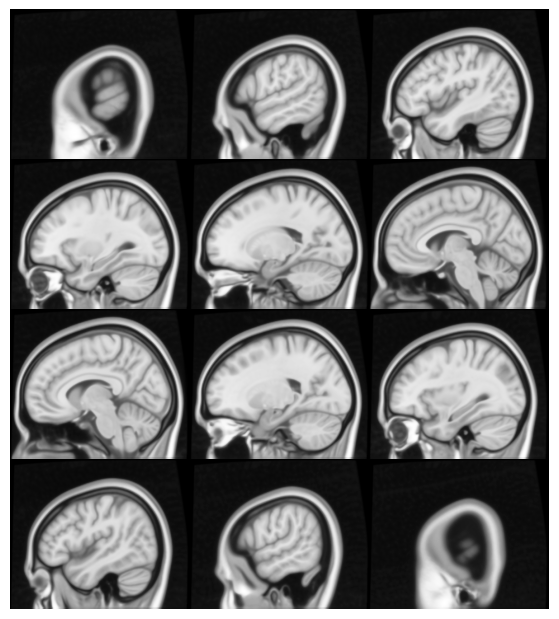

In [9]:
ants.plot(mni_t1)

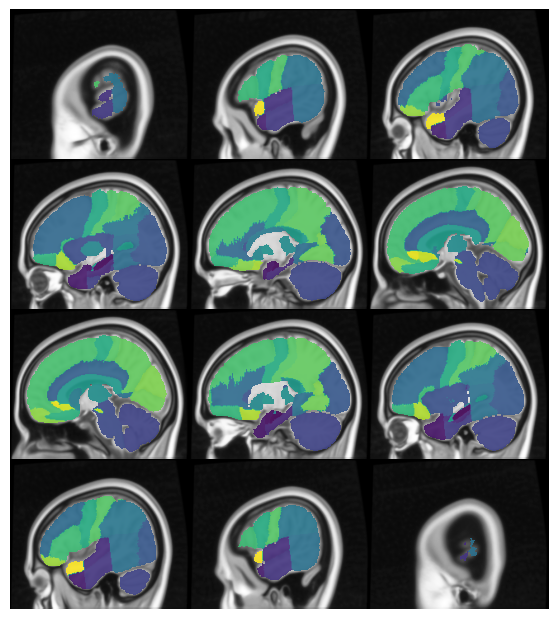

In [10]:
ants.plot(mni_t1, overlay= bm, cmap='Greys_r', overlay_cmap='viridis', overlay_alpha=0.9)

In [11]:
for i in range(0,np.shape(meta)[0]):
    name = meta['Image.Data.ID'][i]+'_registered.nii'
    filename = fnmatch.filter(os.listdir('/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_pet/'), name)
    if len(filename)> 0:
        meta.loc[i,'PATH_registered'] = '/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_pet/' + filename[0]
        
    #print(i)

In [12]:
meta2 = meta[meta['PATH_registered'].notna()]
meta2.reset_index(drop=True, inplace = True)

In [14]:
meta2.shape

(3110, 40)

In [13]:
# preparation of brain areas masks 
brain_areas = np.unique(brain_map)[1:]
area_masks = []
for area in tqdm_notebook(brain_areas):
    area_mask = np.zeros_like(brain_map)
    area_mask[brain_map == area] = 1
    #area_mask = resize_image(area_mask, mni_t1.numpy().shape, interpolation=0)
    area_masks.append(area_mask)
 

/csc/epitkane/home/atagmazi/.conda/envs/atagmazi_gpu8/lib/python3.7/site-packages/ipykernel_launcher.py:4: TqdmDeprecationWarning:

This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`



  0%|          | 0/83 [00:00<?, ?it/s]

In [15]:
brain_dict = {}
for i in range(len(brain_labels)):
    brain_dict[brain_labels[i]] = area_masks[i].copy()

In [16]:
prefered_order = ['Brainstem_sum','Corp_Callosum_sum',
'ThirdVentricl_sum',
'Hippocampus_r_sum',
'Hippocampus_l_sum',
'Amygdala_r_sum',
'Amygdala_l_sum',
'Ant_TL_med_r_sum',
'Ant_TL_med_l_sum',
'Ant_TL_inf_lat_r_sum',
'Ant_TL_inf_lat_l_sum',
'G_paraH_amb_r_sum',
'G_paraH_amb_l_sum',
'G_sup_temp_cent_r_sum',
'G_sup_temp_cent_l_sum',
'G_tem_midin_r_sum',
'G_tem_midin_l_sum',
'G_occtem_la_r_sum',
'G_occtem_la_l_sum',
'Cerebellum_r_sum',
'Cerebellum_l_sum',
'Insula_l_sum',
'Insula_r_sum',
'OL_rest_lat_l_sum',
'OL_rest_lat_r_sum',
'G_cing_ant_sup_l_sum',
'G_cing_ant_sup_r_sum',
'G_cing_post_l_sum',
'G_cing_post_r_sum',
'FL_mid_fr_G_l_sum',
'FL_mid_fr_G_r_sum',
'PosteriorTL_l_sum',
'PosteriorTL_r_sum',
'PL_rest_l_sum',
'PL_rest_r_sum',
'CaudateNucl_l_sum',
'CaudateNucl_r_sum',
'NuclAccumb_l_sum',
'NuclAccumb_r_sum',
'Putamen_l_sum',
'Putamen_r_sum',
'Thalamus_l_sum',
'Thalamus_r_sum',
'Pallidum_l_sum',
'Pallidum_r_sum',
'FrontalHorn_r_sum',
'FrontalHorn_l_sum',
'TemporaHorn_r_sum',
'TemporaHorn_l_sum',
'FL_precen_G_l_sum',
'FL_precen_G_r_sum',
'FL_strai_G_l_sum',
'FL_strai_G_r_sum',
'FL_OFC_AOG_l_sum',
'FL_OFC_AOG_r_sum',
'FL_inf_fr_G_l_sum',
'FL_inf_fr_G_r_sum',
'FL_sup_fr_G_l_sum',
'FL_sup_fr_G_r_sum',
'PL_postce_G_l_sum',
'PL_postce_G_r_sum',
'PL_sup_pa_G_l_sum',
'PL_sup_pa_G_r_sum',
'OL_ling_G_l_sum',
'OL_ling_G_r_sum',
'OL_cuneus_l_sum',
'OL_cuneus_r_sum',
'FL_OFC_MOG_l_sum',
'FL_OFC_MOG_r_sum',
'FL_OFC_LOG_l_sum',
'FL_OFC_LOG_r_sum',
'FL_OFC_POG_l_sum',
'FL_OFC_POG_r_sum',
'S_nigra_l_sum',
'S_nigra_r_sum',
'Subgen_antCing_l_sum',
'Subgen_antCing_r_sum',
'Subcall_area_l_sum',
'Subcall_area_r_sum',
'Presubgen_antCing_l_sum',
'Presubgen_antCing_r_sum',
'G_sup_temp_ant_l_sum',
'G_sup_temp_ant_r_sum']

In [17]:
brain_dict_ordered = {}
for i in range(len(prefered_order)):
    brain_dict_ordered[prefered_order[i]] = brain_dict[prefered_order[i]]

In [18]:
brain_labels_merged = ['Brainstem_sum','Corp_Callosum_sum',
'ThirdVentricl_sum',
'Hippocampus_sum',
'Amygdala_sum',
'Ant_TL_med_sum',
'Ant_TL_inf_lat_sum',
'G_paraH_amb_sum',
'G_sup_temp_cent_sum',
'G_tem_midin_sum',
'G_occtem_la_sum',
'Cerebellum_sum',
'Insula_sum',
'OL_rest_lat_sum',
'G_cing_ant_sup_sum',
'G_cing_post_sum',
'FL_mid_fr_G_sum',
'PosteriorTL_sum',
'PL_rest_sum',
'CaudateNucl_sum',
'NuclAccumb_sum',
'Putamen_sum',
'Thalamus_sum',
'Pallidum_sum',
'FrontalHorn_sum',
'TemporaHorn_sum',
'FL_precen_G_sum',
'FL_strai_G_sum',
'FL_OFC_AOG_sum',
'FL_inf_fr_G_sum',
'FL_sup_fr_G_sum',
'PL_postce_G_sum',
'PL_sup_pa_G_sum',
'OL_ling_G_sum',
'OL_cuneus_sum',
'FL_OFC_MOG_sum',
'FL_OFC_LOG_sum',
'FL_OFC_POG_sum',
'S_nigra_sum',
'Subgen_antCing_sum',
'Subcall_area_sum',
'Presubgen_antCing_sum',
'G_sup_temp_ant_sum']

In [19]:
# merge right and left hemisphere masks Hammas atlas
brain_dict_merged = {}
for i in range(0,3):
    brain_dict_merged[brain_labels_merged[i]] = brain_dict_ordered[prefered_order[i]]

name = 3
for i in range(3,len(prefered_order),2):
    brain_dict_merged[brain_labels_merged[name]] = brain_dict_ordered[prefered_order[i]] + brain_dict_ordered[prefered_order[i+1]]
    name +=1

(-0.5, 181.5, 181.5, -0.5)

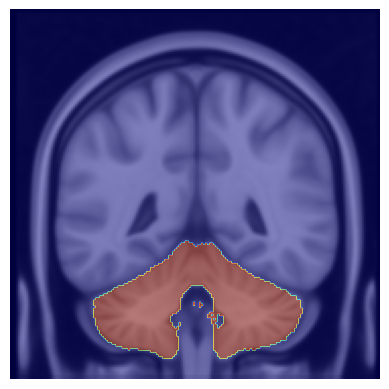

In [20]:
plt.imshow(np.rot90(mni_t1[:, 80, :].copy()), cmap = 'gray')
plt.imshow(np.rot90(brain_dict_merged['Cerebellum_sum'][:, 80, :].copy()), cmap = 'jet',alpha = 0.5) 
plt.axis('off')

In [21]:
Cerebellum = brain_dict_merged['Cerebellum_sum']

In [22]:
def get_cerebellum_intensity(pet_scan):
    cerebellum_intensity = np.sum(pet_scan * Cerebellum)/np.sum(Cerebellum)
    pet_normalised = pet_scan/cerebellum_intensity
    return pet_normalised

In [23]:
summary_before = []
summary_after = []
failed = []
for img in meta2.loc[:2,'PATH_registered']: 
    imag=nib.load(meta2.loc[0,'PATH_registered'])
    image = imag.get_fdata()
    summary_before.append(np.isnan(image).any())
    image_norm = get_cerebellum_intensity(image)
    image_norm[image_norm<0] = 0
    minimum = np.min(image_norm)
    maximum = np.max(image_norm)
    #image_norm = image_norm - minimum
    summary_after.append(np.isnan(image_norm).any())
    if np.isnan(image).any() or np.isnan(image_norm).any():
        failed.append(meta2.loc[i,'Image.ID'])

In [24]:
summary_before

[False, False, False]

In [25]:
failed

[]

In [26]:
# I run it right in Jupyter notebook because slurm returned me an error and 
# it's not that heavy for notebook just take some time. 
max_intensity = []
min_intensity = []
median_intensity = []
zeros = []
failed = []
#meta2['maximum_intensity'] = 0
cerebel = []
i = 0

summary_before = []
summary_after = []
for img in meta2.loc[:,'PATH_registered']: #!!
    imag=nib.load(img)
    image = imag.get_fdata()
    summary_before.append(np.isnan(image).any())
    image_norm = get_cerebellum_intensity(image)
    if len(image_norm[image_norm<0])>0:
        zeros.append(meta2.loc[i,'Project'])
    image_norm[image_norm<0] = 0
    summary_after.append(np.isnan(image_norm).any())
    
    if np.isnan(image).any() or np.isnan(image_norm).any():
        failed.append(meta2.loc[i,'Image.ID'])
    #minimum = np.min(image_norm)
    #image_norm = image_norm - minimum
    nii_image = nib.Nifti1Image(image_norm, imag.affine, imag.header)
    nib.save(nii_image, '/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_normalised_pet/' 
             + meta2.loc[i,'Image.Data.ID']+'_normalised.nii')
    max_intensity.append(np.max(image_norm))
    min_intensity.append(np.min(image_norm))
    print(i)
    i+=1

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

1861
1862
1863
1864
1865
1866
1867
1868
1869
1870
1871
1872
1873
1874
1875
1876
1877
1878
1879
1880
1881
1882
1883
1884
1885
1886
1887
1888
1889
1890
1891
1892
1893
1894
1895
1896
1897
1898
1899
1900
1901
1902
1903
1904
1905
1906
1907
1908
1909
1910
1911
1912
1913
1914
1915
1916
1917
1918
1919
1920
1921
1922
1923
1924
1925
1926
1927
1928
1929
1930
1931
1932
1933
1934
1935
1936
1937
1938
1939
1940
1941
1942
1943
1944
1945
1946
1947
1948
1949
1950
1951
1952
1953
1954
1955
1956
1957
1958
1959
1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025
2026
2027
2028
2029
2030
2031
2032
2033
2034
2035
2036
2037
2038
2039
2040
2041
2042
2043
2044
2045
2046
2047
2048
2049
2050
2051
2052
2053
2054
2055
2056
2057
2058
2059
2060


In [ ]:
sys.exit()

In [ ]:
# OLD CODE

In [38]:
#brain_labels['name'].values

array(['3rd Ventricle', '4th Ventricle', 'Right Accumbens Area',
       'Left Accumbens Area', 'Right Amygdala', 'Left Amygdala',
       'Brain Stem', 'Right Caudate', 'Left Caudate',
       'Right Cerebellum Exterior', 'Left Cerebellum Exterior',
       'Right Cerebellum White Matter', 'Left Cerebellum White Matter',
       'Right Cerebral White Matter', 'Left Cerebral White Matter', 'CSF',
       'Right Hippocampus', 'Left Hippocampus', 'Right Inf Lat Vent',
       'Left Inf Lat Vent', 'Right Lateral Ventricle',
       'Left Lateral Ventricle', 'Right Pallidum', 'Left Pallidum',
       'Right Putamen', 'Left Putamen', 'Right Thalamus Proper',
       'Left Thalamus Proper', 'Right Ventral DC', 'Left Ventral DC',
       'Right vessel', 'Left vessel', 'Optic Chiasm',
       'Cerebellar Vermal Lobules I-V',
       'Cerebellar Vermal Lobules VI-VII',
       'Cerebellar Vermal Lobules VIII-X', 'Left Basal Forebrain',
       'Right Basal Forebrain', 'Right ACgG anterior cingulate gyrus',
  

In [39]:
'''brain_dict = {}
for i in range(len(brain_labels['name'])):
    brain_dict[brain_labels['name'][i]] = area_masks[i].copy()'''

In [40]:
#Cerebellum = area_masks[9]+area_masks[10]+area_masks[11]+area_masks[12]

In [41]:
def get_cerebellum_intensity(pet_scan):
    cerebellum_intensity = np.sum(pet_scan * Cerebellum)/np.sum(Cerebellum)
    pet_normalised = pet_scan/cerebellum_intensity
    return pet_normalised

In [42]:
summary_before = []
summary_after = []
for img in meta2.loc[:2,'PATH_registered']: 
    imag=nib.load(meta2.loc[0,'PATH_registered'])
    image = imag.get_fdata()
    summary_before.append(np.isnan(image).any())
    image_norm = get_cerebellum_intensity(image)
    image_norm[image_norm<0] = 0
    minimum = np.min(image_norm)
    maximum = np.max(image_norm)
    #image_norm = image_norm - minimum
    summary_after.append(np.isnan(image_norm).any())

In [43]:
len(image_norm[image_norm<0])

0

In [44]:
# I run it right in Jupyter notebook because slurm returned me an error and 
# it's not that heavy for notebook just take some time. 
max_intensity = []
min_intensity = []
median_intensity = []
zeros = []
#meta2['maximum_intensity'] = 0
cerebel = []
i = 0

summary_before = []
summary_after = []
for img in meta2.loc[:,'PATH_registered']: #!!
    imag=nib.load(img)
    image = imag.get_fdata()
    summary_before.append(np.isnan(image).any())
    image_norm = get_cerebellum_intensity(image)
    if len(image_norm[image_norm<0])>0:
        zeros.append(meta2.loc[i,'Project'])
    image_norm[image_norm<0] = 0
    summary_after.append(np.isnan(image_norm).any())
    #minimum = np.min(image_norm)
    #image_norm = image_norm - minimum
    nii_image = nib.Nifti1Image(image_norm, imag.affine, imag.header)
    nib.save(nii_image, '/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_normalised_pet/' 
             + meta2.loc[i,'Image.Data.ID']+'_normalised.nii')
    max_intensity.append(np.max(image_norm))
    min_intensity.append(np.min(image_norm))
    print(i)
    i+=1

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025
2026
2027
2028
2029
2030
2031
2032
2033
2034
2035
2036
2037
2038
2039
2040
2041
2042
2043
2044
2045
2046
2047
2048
2049
2050
2051
2052
2053
2054
2055
2056
2057
2058
2059
2060
2061
2062
2063
2064
2065
2066
2067
2068
2069
2070
2071
2072
2073
2074
2075
2076
2077
2078
2079
2080
2081
2082
2083
2084
2085
2086
2087
2088
2089
2090
2091
2092
2093
2094
2095
2096
2097
2098
2099
2100
2101
2102
2103
2104
2105
2106
2107
2108
2109
2110
2111
2112
2113
2114
2115
2116
2117
2118
2119
2120
2121
2122
2123
2124
2125
2126
2127
2128
2129
2130
2131
2132
2133
2134
2135
2136
2137
2138
2139
2140
2141
2142
2143
2144
2145
2146
2147
2148
2149
2150
2151
2152
2153
2154
2155
2156
2157
2158
2159
2160
2161
2162
2163
2164
2165
2166
2167
2168
2169
2170


3610
3611
3612
3613
3614
3615
3616
3617
3618
3619
3620
3621
3622
3623
3624
3625
3626
3627
3628
3629
3630
3631
3632
3633
3634
3635
3636
3637
3638
3639
3640
3641
3642
3643
3644
3645
3646
3647
3648
3649
3650
3651
3652
3653
3654
3655
3656
3657
3658
3659
3660
3661
3662
3663
3664
3665
3666
3667
3668
3669
3670
3671
3672
3673
3674
3675
3676
3677
3678
3679
3680
3681
3682
3683
3684
3685
3686
3687
3688
3689
3690
3691
3692
3693
3694
3695
3696
3697
3698
3699
3700
3701
3702
3703
3704
3705
3706
3707
3708
3709
3710
3711
3712
3713
3714
3715
3716
3717
3718
3719
3720
3721
3722
3723
3724
3725
3726
3727
3728
3729
3730
3731
3732
3733
3734
3735
3736
3737
3738
3739
3740
3741
3742
3743
3744
3745
3746
3747
3748
3749
3750
3751
3752
3753
3754
3755
3756
3757
3758
3759
3760
3761
3762
3763
3764
3765
3766
3767
3768
3769
3770
3771
3772
3773
3774
3775
3776
3777
3778
3779
3780
3781
3782
3783
3784
3785
3786
3787
3788
3789
3790
3791
3792
3793
3794
3795
3796
3797
3798
3799
3800
3801
3802
3803
3804
3805
3806
3807
3808
3809


In [44]:
meta2.loc[0,'Project']

'ADNI'

In [45]:
summary_before.count(True)

0

In [46]:
summary_after.count(True)

0

In [17]:
meta_temp = meta2.copy()
meta_temp['nan_ex'] = summary_after

In [18]:
m = meta_temp[meta_temp['nan_ex'] == True]

In [19]:
m

,Project,Phase,Sex,Weight,Research.Group,Visit,Study.Date,Archive.Date,Age,Modality,Description,Type,Imaging.Protocol,Image.ID,VISCODE,Image.Data.ID,modality_subtype,PATH,PATH_registered,nan_ex
1930,ADNI,ADNI 2,F,81.6,EMCI,ADNI2 Year 4 Visit,12/22/2015,1/20/2016,63.6,PET,"AV45 Co-registered, Averaged <- Dyn_ADNI-GO(12...",Processed,GE MEDICAL SYSTEMS,608641,v41,I608641,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,True


In [39]:
m.loc[:,'PATH_registered']

410     /csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
1782    /csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
2537    /csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
Name: PATH_registered, dtype: object

In [20]:
summary_b = []
summary_a = []
for img in m.loc[:,'PATH_registered']: 
    imag=nib.load(img)
    image = imag.get_fdata()
    summary_b.append(np.isnan(image).any())
    image_norm = get_cerebellum_intensity(image)
    image_norm[image_norm<0] = 0
    minimum = np.min(image_norm)
    maximum = np.max(image_norm)
    #image_norm = image_norm - minimum
    summary_a.append(np.isnan(image_norm).any())

/csc/epitkane/home/atagmazi/.conda/envs/atagmazi_gpu8/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning:

divide by zero encountered in true_divide

/csc/epitkane/home/atagmazi/.conda/envs/atagmazi_gpu8/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning:

invalid value encountered in true_divide



In [26]:
summary_b = []
summary_a = []
for img in meta2.loc[:4,'PATH_registered']: 
    imag=nib.load(img)
    image = imag.get_fdata()
    summary_b.append(np.isnan(image).any())
    image_norm = get_cerebellum_intensity(image)
    image_norm[image_norm<0] = 0
    minimum = np.min(image_norm)
    maximum = np.max(image_norm)
    #image_norm = image_norm - minimum
    summary_a.append(np.isnan(image_norm).any())

In [46]:
np.sum(image * Cerebellum)/np.sum(Cerebellum)

0.0

In [52]:
mni_t1

ANTsImage (LPI)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (197, 233, 189)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (98.0, 134.0, -72.0)
	 Direction  : [-1.  0.  0.  0. -1.  0.  0.  0.  1.]

In [22]:
origin = (98.0, 134.0, -72.0)
spacing = (1.0, 1.0, 1.0)
direction = [[-1.,  0.,  0.],
       [ 0., -1.,  0.],
       [ 0.,  0.,  1.]]

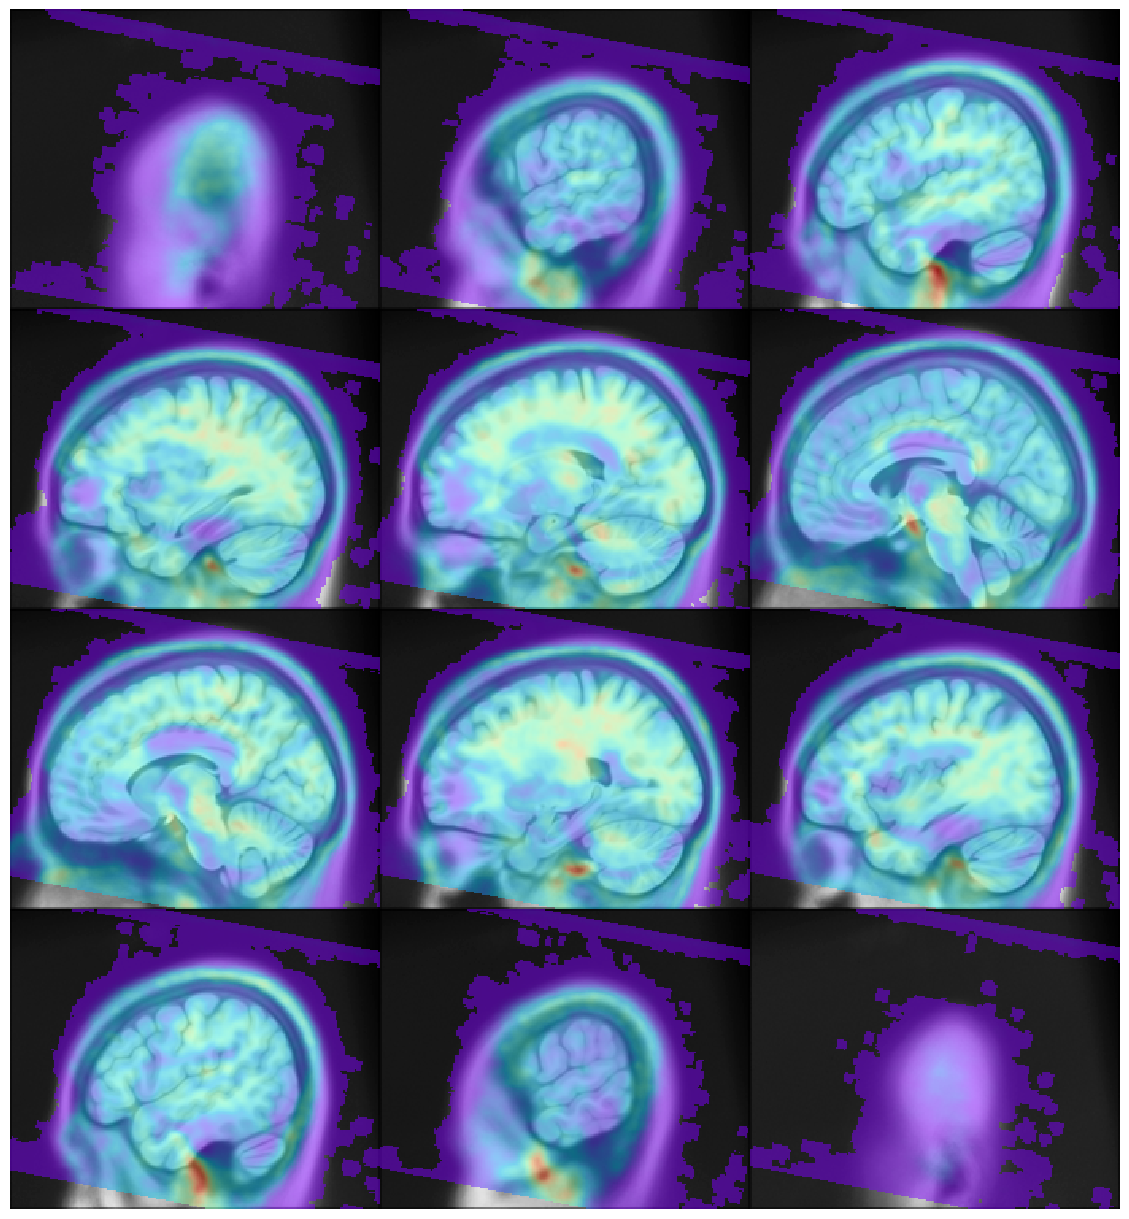

In [30]:
ants.plot( mni_t1, 
          ants.from_numpy(image,origin=origin, spacing=spacing,direction=direction),
          overlay_alpha = 0.5,figsize=3, overlay_cmap = 'rainbow')

In [45]:
image * Cerebellum

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [41]:
np.isnan(image_norm).any()

True

In [47]:
'''# Hammer brain atlas
mni_t1 = ants.image_read('/csc/epitkane/home/atagmazi/Downloads/mni_icbm152_nlin_sym_09a_nifti/mni_icbm152_nlin_sym_09a/mni_icbm152_t1_tal_nlin_sym_09a.nii')
bm = ants.image_read('/csc/epitkane/home/atagmazi/Hammer_brain_atlas/Hammers_mith_atlas_n30r83_SPM5.nii.gz').astype('uint32')
brain_map =  ants.resample_image_to_target(bm, mni_t1, interp_type='nearestNeighbor').astype('uint32').numpy()'''

In [48]:
'''brain_labels = ['Hippocampus_r_sum',
'Hippocampus_l_sum',
'Amygdala_r_sum',
'Amygdala_l_sum',
'Ant_TL_med_r_sum',
'Ant_TL_med_l_sum',
'Ant_TL_inf_lat_r_sum',
'Ant_TL_inf_lat_l_sum',
'G_paraH_amb_r_sum',
'G_paraH_amb_l_sum',
'G_sup_temp_cent_r_sum',
'G_sup_temp_cent_l_sum',
'G_tem_midin_r_sum',
'G_tem_midin_l_sum',
'G_occtem_la_r_sum',
'G_occtem_la_l_sum',
'Cerebellum_r_sum',
'Cerebellum_l_sum',
'Brainstem_sum',
'Insula_l_sum',
'Insula_r_sum',
'OL_rest_lat_l_sum',
'OL_rest_lat_r_sum',
'G_cing_ant_sup_l_sum',
'G_cing_ant_sup_r_sum',
'G_cing_post_l_sum',
'G_cing_post_r_sum',
'FL_mid_fr_G_l_sum',
'FL_mid_fr_G_r_sum',
'PosteriorTL_l_sum',
'PosteriorTL_r_sum',
'PL_rest_l_sum',
'PL_rest_r_sum',
'CaudateNucl_l_sum',
'CaudateNucl_r_sum',
'NuclAccumb_l_sum',
'NuclAccumb_r_sum',
'Putamen_l_sum',
'Putamen_r_sum',
'Thalamus_l_sum',
'Thalamus_r_sum',
'Pallidum_l_sum',
'Pallidum_r_sum',
'Corp_Callosum_sum',
'FrontalHorn_r_sum',
'FrontalHorn_l_sum',
'TemporaHorn_r_sum',
'TemporaHorn_l_sum',
'ThirdVentricl_sum',
'FL_precen_G_l_sum',
'FL_precen_G_r_sum',
'FL_strai_G_l_sum',
'FL_strai_G_r_sum',
'FL_OFC_AOG_l_sum',
'FL_OFC_AOG_r_sum',
'FL_inf_fr_G_l_sum',
'FL_inf_fr_G_r_sum',
'FL_sup_fr_G_l_sum',
'FL_sup_fr_G_r_sum',
'PL_postce_G_l_sum',
'PL_postce_G_r_sum',
'PL_sup_pa_G_l_sum',
'PL_sup_pa_G_r_sum',
'OL_ling_G_l_sum',
'OL_ling_G_r_sum',
'OL_cuneus_l_sum',
'OL_cuneus_r_sum',
'FL_OFC_MOG_l_sum',
'FL_OFC_MOG_r_sum',
'FL_OFC_LOG_l_sum',
'FL_OFC_LOG_r_sum',
'FL_OFC_POG_l_sum',
'FL_OFC_POG_r_sum',
'S_nigra_l_sum',
'S_nigra_r_sum',
'Subgen_antCing_l_sum',
'Subgen_antCing_r_sum',
'Subcall_area_l_sum',
'Subcall_area_r_sum',
'Presubgen_antCing_l_sum',
'Presubgen_antCing_r_sum',
'G_sup_temp_ant_l_sum',
'G_sup_temp_ant_r_sum']'''

In [51]:
meta2.shape

(4931, 19)

In [54]:
prefered_order = ['Brainstem_sum','Corp_Callosum_sum',
'ThirdVentricl_sum',
'Hippocampus_r_sum',
'Hippocampus_l_sum',
'Amygdala_r_sum',
'Amygdala_l_sum',
'Ant_TL_med_r_sum',
'Ant_TL_med_l_sum',
'Ant_TL_inf_lat_r_sum',
'Ant_TL_inf_lat_l_sum',
'G_paraH_amb_r_sum',
'G_paraH_amb_l_sum',
'G_sup_temp_cent_r_sum',
'G_sup_temp_cent_l_sum',
'G_tem_midin_r_sum',
'G_tem_midin_l_sum',
'G_occtem_la_r_sum',
'G_occtem_la_l_sum',
'Cerebellum_r_sum',
'Cerebellum_l_sum',
'Insula_l_sum',
'Insula_r_sum',
'OL_rest_lat_l_sum',
'OL_rest_lat_r_sum',
'G_cing_ant_sup_l_sum',
'G_cing_ant_sup_r_sum',
'G_cing_post_l_sum',
'G_cing_post_r_sum',
'FL_mid_fr_G_l_sum',
'FL_mid_fr_G_r_sum',
'PosteriorTL_l_sum',
'PosteriorTL_r_sum',
'PL_rest_l_sum',
'PL_rest_r_sum',
'CaudateNucl_l_sum',
'CaudateNucl_r_sum',
'NuclAccumb_l_sum',
'NuclAccumb_r_sum',
'Putamen_l_sum',
'Putamen_r_sum',
'Thalamus_l_sum',
'Thalamus_r_sum',
'Pallidum_l_sum',
'Pallidum_r_sum',
'FrontalHorn_r_sum',
'FrontalHorn_l_sum',
'TemporaHorn_r_sum',
'TemporaHorn_l_sum',
'FL_precen_G_l_sum',
'FL_precen_G_r_sum',
'FL_strai_G_l_sum',
'FL_strai_G_r_sum',
'FL_OFC_AOG_l_sum',
'FL_OFC_AOG_r_sum',
'FL_inf_fr_G_l_sum',
'FL_inf_fr_G_r_sum',
'FL_sup_fr_G_l_sum',
'FL_sup_fr_G_r_sum',
'PL_postce_G_l_sum',
'PL_postce_G_r_sum',
'PL_sup_pa_G_l_sum',
'PL_sup_pa_G_r_sum',
'OL_ling_G_l_sum',
'OL_ling_G_r_sum',
'OL_cuneus_l_sum',
'OL_cuneus_r_sum',
'FL_OFC_MOG_l_sum',
'FL_OFC_MOG_r_sum',
'FL_OFC_LOG_l_sum',
'FL_OFC_LOG_r_sum',
'FL_OFC_POG_l_sum',
'FL_OFC_POG_r_sum',
'S_nigra_l_sum',
'S_nigra_r_sum',
'Subgen_antCing_l_sum',
'Subgen_antCing_r_sum',
'Subcall_area_l_sum',
'Subcall_area_r_sum',
'Presubgen_antCing_l_sum',
'Presubgen_antCing_r_sum',
'G_sup_temp_ant_l_sum',
'G_sup_temp_ant_r_sum']

In [55]:
brain_dict_ordered = {}
for i in range(len(prefered_order)):
    brain_dict_ordered[prefered_order[i]] = brain_dict[prefered_order[i]]

In [56]:
brain_labels_merged = ['Brainstem_sum','Corp_Callosum_sum',
'ThirdVentricl_sum',
'Hippocampus_sum',
'Amygdala_sum',
'Ant_TL_med_sum',
'Ant_TL_inf_lat_sum',
'G_paraH_amb_sum',
'G_sup_temp_cent_sum',
'G_tem_midin_sum',
'G_occtem_la_sum',
'Cerebellum_sum',
'Insula_sum',
'OL_rest_lat_sum',
'G_cing_ant_sup_sum',
'G_cing_post_sum',
'FL_mid_fr_G_sum',
'PosteriorTL_sum',
'PL_rest_sum',
'CaudateNucl_sum',
'NuclAccumb_sum',
'Putamen_sum',
'Thalamus_sum',
'Pallidum_sum',
'FrontalHorn_sum',
'TemporaHorn_sum',
'FL_precen_G_sum',
'FL_strai_G_sum',
'FL_OFC_AOG_sum',
'FL_inf_fr_G_sum',
'FL_sup_fr_G_sum',
'PL_postce_G_sum',
'PL_sup_pa_G_sum',
'OL_ling_G_sum',
'OL_cuneus_sum',
'FL_OFC_MOG_sum',
'FL_OFC_LOG_sum',
'FL_OFC_POG_sum',
'S_nigra_sum',
'Subgen_antCing_sum',
'Subcall_area_sum',
'Presubgen_antCing_sum',
'G_sup_temp_ant_sum']

In [57]:
# merge right and left hemisphere masks
brain_dict_merged = {}
for i in range(0,3):
    brain_dict_merged[brain_labels_merged[i]] = brain_dict_ordered[prefered_order[i]]

name = 3
for i in range(3,len(prefered_order),2):
    brain_dict_merged[brain_labels_merged[name]] = brain_dict_ordered[prefered_order[i]] + brain_dict_ordered[prefered_order[i+1]]
    name +=1

In [58]:
brain_dict_merged['Cerebellum_sum']

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [59]:
def get_cerebellum_intensity(pet_scan):
    cerebellum_intensity = np.sum(pet_scan * brain_dict_merged['Cerebellum_sum'])/np.sum(brain_dict_merged['Cerebellum_sum'])
    pet_normalised = pet_scan/cerebellum_intensity
    return pet_normalised 

In [60]:
summary = []
for img in meta2.loc[:2,'PATH_registered']: 
    imag=nib.load(meta2.loc[0,'PATH_registered'])
    image = imag.get_fdata()
    image_norm = get_cerebellum_intensity(image)
    image_norm[image_norm<0] = 0
    minimum = np.min(image_norm)
    maximum = np.max(image_norm)
    #image_norm = image_norm - minimum
    summary.append(np.isnan(image_norm).any())

In [62]:
# I run it right in Jupyter notebook because slurm returned me an error and 
# it's not that heavy for notebook just take some time. 
max_intensity = []
min_intensity = []
median_intensity = []
zeros = []
#meta2['maximum_intensity'] = 0
cerebel = []
i = 0
summary_before = []
summary_after = []
for img in meta2.loc[:,'PATH_registered']: #!!
    imag=nib.load(img)
    image = imag.get_fdata()
    summary_before.append(np.isnan(image).any())
    image_norm = get_cerebellum_intensity(image)
    if len(image_norm[image_norm<0])>0:
        zeros.append(meta2.loc[i,'Project'])
    image_norm[image_norm<0] = 0
    summary_after.append(np.isnan(image_norm).any())
    #minimum = np.min(image_norm)
    #image_norm = image_norm - minimum
    nii_image = nib.Nifti1Image(image_norm, imag.affine, imag.header)
    nib.save(nii_image, '/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_normalised_pet/' 
             + meta2.loc[i,'Image.Data.ID']+'_normalised.nii')
    max_intensity.append(np.max(image_norm))
    min_intensity.append(np.min(image_norm))
    print(i)
    i+=1

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

/csc/epitkane/home/atagmazi/.conda/envs/atagmazi_gpu8/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning:

divide by zero encountered in true_divide

/csc/epitkane/home/atagmazi/.conda/envs/atagmazi_gpu8/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning:

invalid value encountered in true_divide



410
411
412
413
414
415
416
417
418
419
420
421
422
423
424
425
426
427
428
429
430
431
432
433
434
435
436
437
438
439
440
441
442
443
444
445
446
447
448
449
450
451
452
453
454
455
456
457
458
459
460
461
462
463
464
465
466
467
468
469
470
471
472
473
474
475
476
477
478
479
480
481
482
483
484
485
486
487
488
489
490
491
492
493
494
495
496
497
498
499
500
501
502
503
504
505
506
507
508
509
510
511
512
513
514
515
516
517
518
519
520
521
522
523
524
525
526
527
528
529
530
531
532
533
534
535
536
537
538
539
540
541
542
543
544
545
546
547
548
549
550
551
552
553
554
555
556
557
558
559
560
561
562
563
564
565
566
567
568
569
570
571
572
573
574
575
576
577
578
579
580
581
582
583
584
585
586
587
588
589
590
591
592
593
594
595
596
597
598
599
600
601
602
603
604
605
606
607
608
609
610
611
612
613
614
615
616
617
618
619
620
621
622
623
624
625
626
627
628
629
630
631
632
633
634
635
636
637
638
639
640
641
642
643
644
645
646
647
648
649
650
651
652
653
654
655
656
657
658
659


2167
2168
2169
2170
2171
2172
2173
2174
2175
2176
2177
2178
2179
2180
2181
2182
2183
2184
2185
2186
2187
2188
2189
2190
2191
2192
2193
2194
2195
2196
2197
2198
2199
2200
2201
2202
2203
2204
2205
2206
2207
2208
2209
2210
2211
2212
2213
2214
2215
2216
2217
2218
2219
2220
2221
2222
2223
2224
2225
2226
2227
2228
2229
2230
2231
2232
2233
2234
2235
2236
2237
2238
2239
2240
2241
2242
2243
2244
2245
2246
2247
2248
2249
2250
2251
2252
2253
2254
2255
2256
2257
2258
2259
2260
2261
2262
2263
2264
2265
2266
2267
2268
2269
2270
2271
2272
2273
2274
2275
2276
2277
2278
2279
2280
2281
2282
2283
2284
2285
2286
2287
2288
2289
2290
2291
2292
2293
2294
2295
2296
2297
2298
2299
2300
2301
2302
2303
2304
2305
2306
2307
2308
2309
2310
2311
2312
2313
2314
2315
2316
2317
2318
2319
2320
2321
2322
2323
2324
2325
2326
2327
2328
2329
2330
2331
2332
2333
2334
2335
2336
2337
2338
2339
2340
2341
2342
2343
2344
2345
2346
2347
2348
2349
2350
2351
2352
2353
2354
2355
2356
2357
2358
2359
2360
2361
2362
2363
2364
2365
2366


KeyboardInterrupt: 

In [68]:
summary_before.count(False)

3744

In [69]:
summary_after.count(True)

3

In [ ]:
##############old script ################

In [30]:
len(area_masks)

136

In [31]:
brain_labels['name'].values

array(['3rd Ventricle', '4th Ventricle', 'Right Accumbens Area',
       'Left Accumbens Area', 'Right Amygdala', 'Left Amygdala',
       'Brain Stem', 'Right Caudate', 'Left Caudate',
       'Right Cerebellum Exterior', 'Left Cerebellum Exterior',
       'Right Cerebellum White Matter', 'Left Cerebellum White Matter',
       'Right Cerebral White Matter', 'Left Cerebral White Matter', 'CSF',
       'Right Hippocampus', 'Left Hippocampus', 'Right Inf Lat Vent',
       'Left Inf Lat Vent', 'Right Lateral Ventricle',
       'Left Lateral Ventricle', 'Right Pallidum', 'Left Pallidum',
       'Right Putamen', 'Left Putamen', 'Right Thalamus Proper',
       'Left Thalamus Proper', 'Right Ventral DC', 'Left Ventral DC',
       'Right vessel', 'Left vessel', 'Optic Chiasm',
       'Cerebellar Vermal Lobules I-V',
       'Cerebellar Vermal Lobules VI-VII',
       'Cerebellar Vermal Lobules VIII-X', 'Left Basal Forebrain',
       'Right Basal Forebrain', 'Right ACgG anterior cingulate gyrus',
  

In [32]:
Cerebellum = area_masks[9]+area_masks[10]+area_masks[11]+area_masks[12]

In [33]:
np.sum(Cerebellum)

170769

In [34]:
def get_cerebellum_intensity(pet_scan):
    cerebellum_intensity = np.sum(pet_scan * Cerebellum)/np.sum(Cerebellum)
    pet_normalised = pet_scan/cerebellum_intensity
    return pet_normalised 

In [41]:
summary_before = []
summary_after = []
for img in meta2.loc[:2,'PATH_registered']: 
    imag=nib.load(meta2.loc[0,'PATH_registered'])
    image = imag.get_fdata()
    summary_before.append(np.isnan(image).any())
    image_norm = get_cerebellum_intensity(image)
    image_norm[image_norm<0] = 0
    minimum = np.min(image_norm)
    maximum = np.max(image_norm)
    #image_norm = image_norm - minimum
    summary_after.append(np.isnan(image_norm).any())

In [42]:
summary_before

[False, False, False]

In [43]:
summary_after

[False, False, False]

In [22]:
maximum

3.3754888662950444

In [39]:
meta2

,Project,Phase,Sex,Weight,Research.Group,Visit,Study.Date,Archive.Date,Age,Modality,Description,Type,Imaging.Protocol,Image.ID,VISCODE,Image.Data.ID,modality_subtype,PATH,PATH_registered
0,ADNI,ADNI 2,M,73.0,CN,ADNI2 Initial Visit-Cont Pt,6/10/2011,6/16/2011,90.1,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",Processed,Philips Medical Systems,240522,v06,I240522,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
1,ADNI,ADNI 2,F,57.6,CN,ADNI2 Initial Visit-Cont Pt,6/20/2011,6/23/2011,81.5,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",Processed,Philips Medical Systems,241479,v06,I241479,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
2,ADNI,ADNI 2,F,58.1,CN,ADNI2 Year 2 Visit,5/13/2013,5/24/2013,83.4,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",Processed,Philips Medical Systems,373818,v21,I373818,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
3,ADNI,ADNI 2,F,59.0,CN,ADNI2 Year 4 Visit,5/26/2015,6/30/2015,85.5,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",Processed,Philips Medical Systems,499080,v41,I499080,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
4,ADNI,ADNI 3,F,59.0,CN,ADNI3 Initial Visit-Cont Pt,6/15/2017,7/01/2017,87.5,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",Processed,Philips Medical Systems,869908,init,I869908,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4910,A4,NaN,M,53.8,amyloidE,SCV2,1/01/2017,7/24/2020,71.7,PET,"Florbetapir <- [AC],,,2,,,",Processed,NaN,1324682,SCV2,I1324682,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
4911,A4,NaN,M,0.0,amyloidE,SCV2,1/01/2017,2/14/2021,71.4,PET,Florbetapir <- PET Scan,Processed,NaN,1411052,SCV2,I1411052,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
4912,A4,NaN,M,86.0,LEARN amyloidNE,SCV2,1/01/2015,7/24/2020,72.1,PET,Florbetapir <- MNI LZAX LILLY AD 3D BRAIN,Processed,NaN,1324516,SCV2,I1324516,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...
4913,A4,NaN,M,82.0,amyloidE,SCV2,1/01/2016,2/14/2021,83.2,PET,Florbetapir <- PET Scan,Processed,NaN,1410790,SCV2,I1410790,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...


In [50]:
# I run it right in Jupyter notebook because slurm returned me an error and 
# it's not that heavy for notebook just take some time. 
max_intensity = []
min_intensity = []
median_intensity = []
zeros = []
#meta2['maximum_intensity'] = 0
cerebel = []
i = 0

summary_before = []
summary_after = []
for img in meta2.loc[:,'PATH_registered']: #!!
    imag=nib.load(img)
    image = imag.get_fdata()
    summary_before.append(np.isnan(image).any())
    image_norm = get_cerebellum_intensity(image)
    if len(image_norm[image_norm<0])>0:
        zeros.append(meta2.loc[i,'Project'])
    image_norm[image_norm<0] = 0
    summary_after.append(np.isnan(image_norm).any())
    #minimum = np.min(image_norm)
    #image_norm = image_norm - minimum
    nii_image = nib.Nifti1Image(image_norm, imag.affine, imag.header)
    nib.save(nii_image, '/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25_10_23_registered_normalised_pet/' 
             + meta2.loc[i,'Image.Data.ID']+'_normalised.nii')
    max_intensity.append(np.max(image_norm))
    min_intensity.append(np.min(image_norm))
    print(i)
    i+=1

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

1861
1862
1863
1864
1865
1866
1867
1868
1869
1870
1871
1872
1873
1874
1875
1876
1877
1878
1879
1880
1881
1882
1883
1884
1885
1886
1887
1888
1889
1890
1891
1892
1893
1894
1895
1896
1897
1898
1899
1900
1901
1902
1903
1904
1905
1906
1907
1908
1909
1910
1911
1912
1913
1914
1915
1916
1917
1918
1919
1920
1921
1922
1923
1924
1925
1926
1927
1928
1929
1930
1931
1932
1933
1934
1935
1936
1937
1938
1939
1940
1941
1942
1943
1944
1945
1946
1947
1948
1949
1950
1951
1952
1953
1954
1955
1956
1957
1958
1959
1960
1961
1962
1963
1964
1965
1966
1967
1968
1969
1970
1971
1972
1973
1974
1975
1976
1977
1978
1979
1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025
2026
2027
2028
2029
2030
2031
2032
2033
2034
2035
2036
2037
2038
2039
2040
2041
2042
2043
2044
2045
2046
2047
2048
2049
2050
2051
2052
2053
2054
2055
2056
2057
2058
2059
2060


3500
3501
3502
3503
3504
3505
3506
3507
3508
3509
3510
3511
3512
3513
3514
3515
3516
3517
3518
3519
3520
3521
3522
3523
3524
3525
3526
3527
3528
3529
3530
3531
3532
3533
3534
3535
3536
3537
3538
3539
3540
3541
3542
3543
3544
3545
3546
3547
3548
3549
3550
3551
3552
3553
3554
3555
3556
3557
3558
3559
3560
3561
3562
3563
3564
3565
3566
3567
3568
3569
3570
3571
3572
3573
3574
3575
3576
3577
3578
3579
3580
3581
3582
3583
3584
3585
3586
3587
3588
3589
3590
3591
3592
3593
3594
3595
3596
3597
3598
3599
3600
3601
3602
3603
3604
3605
3606
3607
3608
3609
3610
3611
3612
3613
3614
3615
3616
3617
3618
3619
3620
3621
3622
3623
3624
3625
3626
3627
3628
3629
3630
3631
3632
3633
3634
3635
3636
3637
3638
3639
3640
3641
3642
3643
3644
3645
3646
3647
3648
3649
3650
3651
3652
3653
3654
3655
3656
3657
3658
3659
3660
3661
3662
3663
3664
3665
3666
3667
3668
3669
3670
3671
3672
3673
3674
3675
3676
3677
3678
3679
3680
3681
3682
3683
3684
3685
3686
3687
3688
3689
3690
3691
3692
3693
3694
3695
3696
3697
3698
3699


In [49]:
len(image_norm[image_norm<0])>0

True

In [30]:
print(max(max_intensity))

27.5551637426605


In [21]:
print(min(min_intensity))

0.0


(array([   0.,    0.,    0.,    0.,    0., 4096.,    0.,    0.,    0.,
           0.]),
 array([-0.5, -0.4, -0.3, -0.2, -0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5]),
 <a list of 10 Patch objects>)

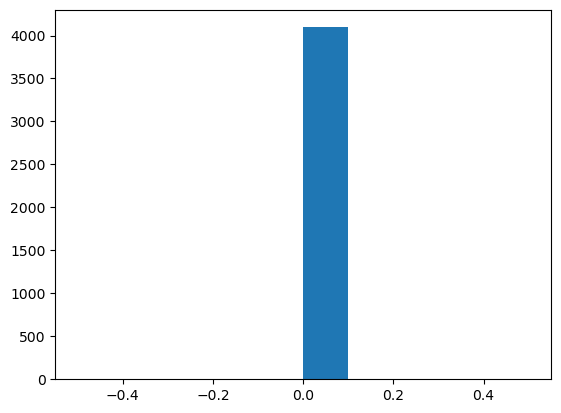

In [24]:
plt.hist(min_intensity)

In [95]:
meta2

,Project,Phase,Sex,Weight,Research.Group,Visit,Study.Date,Archive.Date,Age,Modality,Description,Type,Imaging.Protocol,Image.ID,VISCODE,Image.Data.ID,modality_subtype,PATH,PATH_registered,maximum_intensity
0,ADNI,ADNI 2,M,73.0,CN,ADNI2 Initial Visit-Cont Pt,6/10/2011,6/16/2011,90.1,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",Processed,Philips Medical Systems,240522,v06,I240522,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0
1,ADNI,ADNI 2,F,57.6,CN,ADNI2 Initial Visit-Cont Pt,6/20/2011,6/23/2011,81.5,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",Processed,Philips Medical Systems,241479,v06,I241479,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0
2,ADNI,ADNI 2,F,58.1,CN,ADNI2 Year 2 Visit,5/13/2013,5/24/2013,83.4,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",Processed,Philips Medical Systems,373818,v21,I373818,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0
3,ADNI,ADNI 2,F,59.0,CN,ADNI2 Year 4 Visit,5/26/2015,6/30/2015,85.5,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",Processed,Philips Medical Systems,499080,v41,I499080,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0
4,ADNI,ADNI 3,F,59.0,CN,ADNI3 Initial Visit-Cont Pt,6/15/2017,7/01/2017,87.5,PET,"AV45 Co-registered, Averaged <- ADNI Brain PET...",Processed,Philips Medical Systems,869908,init,I869908,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3125,ADNI,ADNI 3,F,48.1,AD,ADNI Baseline,8/03/2021,8/11/2021,74.8,PET,"FBB Co-registered, Averaged <- PET Brain DYNAM...",Processed,SIEMENS,1479249,bl,I1479249,FBB,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0
3126,ADNI,ADNI 3,M,68.0,CN,ADNI Baseline,10/05/2021,10/21/2021,57.2,PET,"FBB Co-registered, Averaged <- PET Brain - DYN...",Processed,SIEMENS,1507285,bl,I1507285,FBB,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0
3127,A4,NaN,M,75.4,amyloidE,SCV2,1/01/2017,2/21/2021,74.8,PET,Florbetapir <- PET WB,Processed,NaN,1412639,SCV2,I1412639,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0
3128,A4,NaN,F,64.4,amyloidE,SCV2,1/01/2017,2/25/2021,73.8,PET,Florbetapir <- PET Brain50-55,Processed,NaN,1414912,SCV2,I1414912,AV45,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,/csc/epitkane/data/ADNI_A4/ADNI_16_04_22_A4_25...,0


In [98]:
meta2.loc[0,'Image.Data.ID']+'_normalised.nii'

'I240522_normalised.nii'

In [88]:
imag.affine

array([[   1.,    0.,   -0.,  -98.],
       [   0.,    1.,   -0., -134.],
       [   0.,    0.,    1.,  -72.],
       [   0.,    0.,    0.,    1.]])

In [89]:
nib.Nifti1Image(image_norm, imag.affine, imag.header)

In [82]:
max(max_intensity)

20.79050494496289

{'whiskers': [<matplotlib.lines.Line2D at 0x7f8800369d50>,
 'caps': [<matplotlib.lines.Line2D at 0x7f880049c150>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f8800369b90>],
 'medians': [<matplotlib.lines.Line2D at 0x7f880038ed50>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f880037ce10>],
 'means': []}

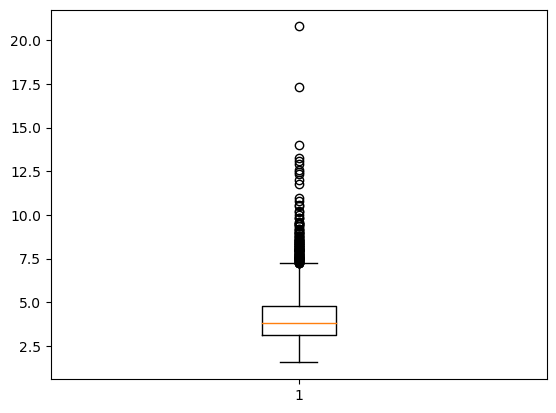

In [83]:
plt.boxplot(max_intensity)

(array([2.690e+03, 1.232e+03, 1.450e+02, 1.800e+01, 7.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 2.000e+00]),
 array([ 1.54628047,  4.1471688 ,  6.74805713,  9.34894545, 11.94983378,
        14.55072211, 17.15161044, 19.75249876, 22.35338709, 24.95427542,
        27.55516374]),
 <a list of 10 Patch objects>)

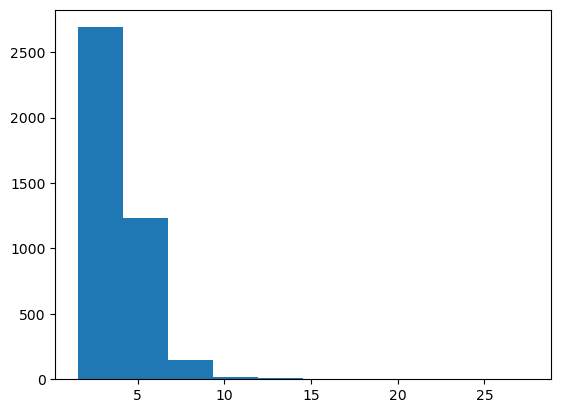

In [114]:
plt.hist(max_intensity)

In [87]:
np.quantile(max_intensity, 0.25)

3.1342470770113704

In [48]:
origin = (98.0, 134.0, -72.0)
spacing = (1.0, 1.0, 1.0)
direction = [[-1.,  0.,  0.],
       [ 0., -1.,  0.],
       [ 0.,  0.,  1.]]

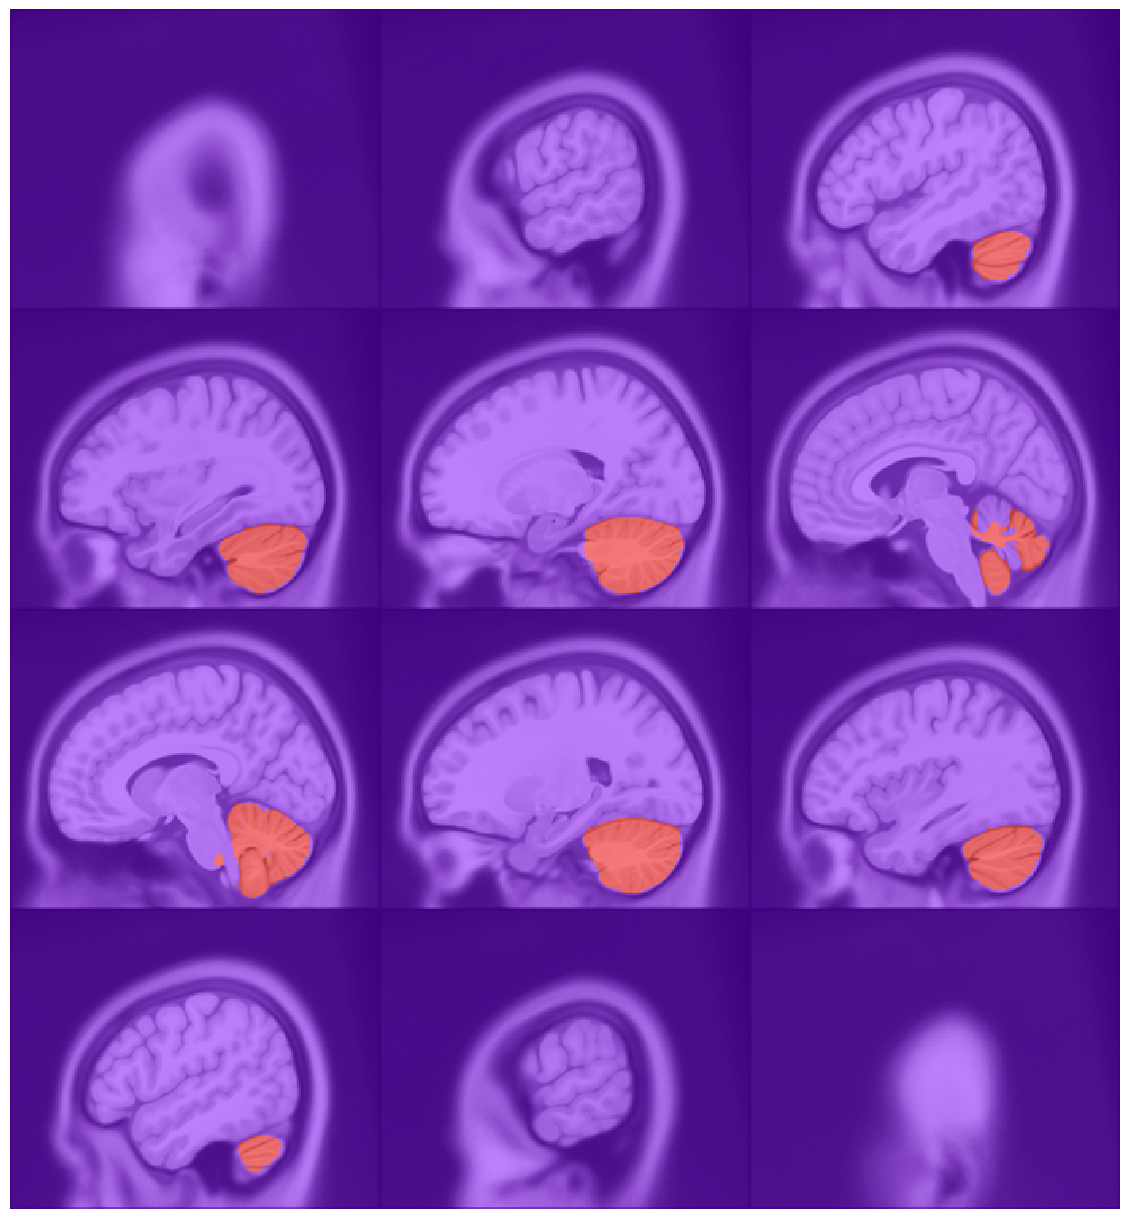

In [87]:
ants.plot( mni_t1, 
          ants.from_numpy(Cerebellum,origin=origin, spacing=spacing,direction=direction),
          overlay_alpha = 0.5,figsize=3, overlay_cmap = 'rainbow')